In [2]:
import pandas as pd 
import matplotlib
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing as ES

In [3]:
df = pd.read_csv('Auto_sales.csv', sep=';', \
    decimal=',', parse_dates=['Date'], \
    index_col='Date')
df = df.dropna()

In [4]:
h = 5

In [5]:
tes_auto = ES(df.iloc[:-h,:].Auto_sales, trend='add',seasonal='mul', seasonal_periods=12).fit()

c:\Users\mrosk\.conda\envs\ml311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [6]:
print(tes_auto.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:               Auto_sales   No. Observations:                  239
Model:             ExponentialSmoothing   SSE                         488693.430
Optimized:                         True   AIC                           1853.903
Trend:                         Additive   BIC                           1909.527
Seasonal:                Multiplicative   AICC                          1857.013
Seasonal Periods:                    12   Date:                 Mon, 21 Oct 2024
Box-Cox:                          False   Time:                         12:01:26
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.5006036                alpha                 True
smoothing_trend          

In [7]:
df['tes_fit'] = tes_auto.fittedvalues

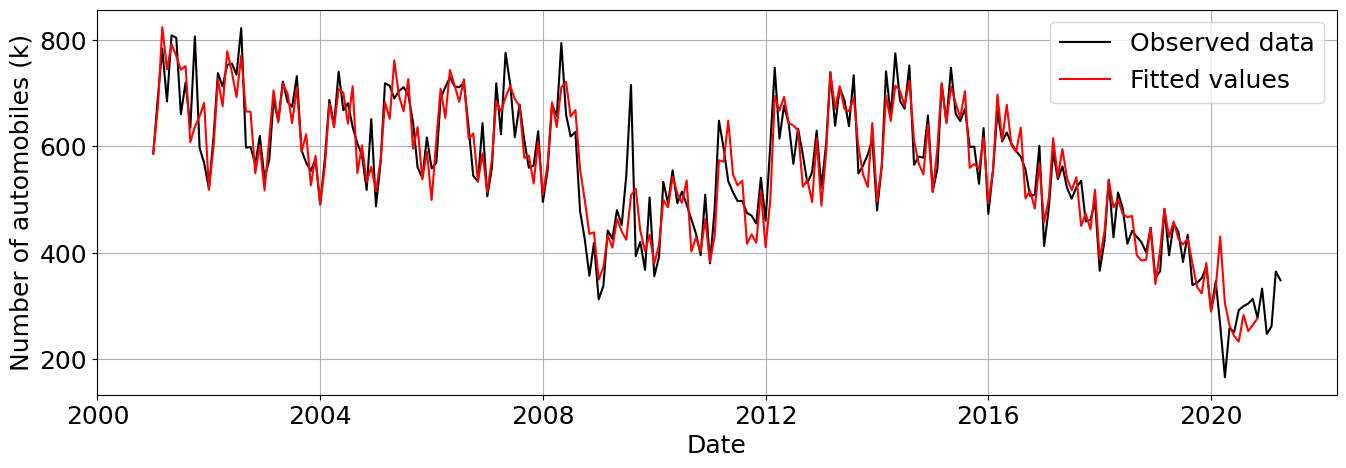

In [8]:
plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(16, 5), dpi=100)

# observed data
plt.plot(df.index, df.Auto_sales, \
    color='k', label='Observed data')

# TES model
plt.plot(df.index, df.tes_fit, \
    color='r', label='Fitted values')

# set artists
plt.gca().set(xlabel='Date', \
    ylabel='Number of automobiles (k)')
plt.legend()
plt.grid()
plt.show()

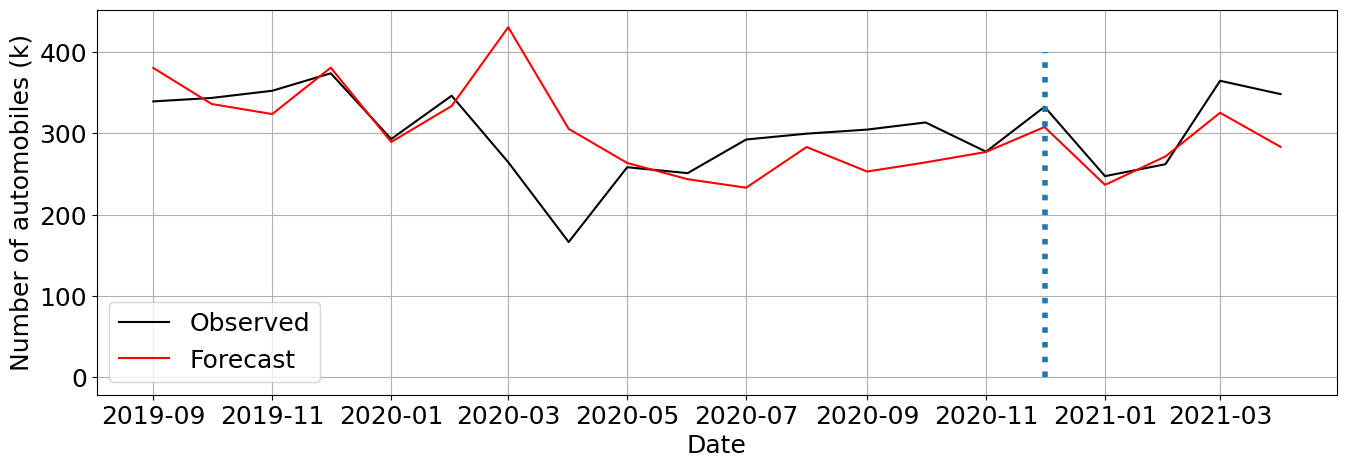

In [9]:
df.tes_fit.iloc[-h:] = tes_auto.forecast(steps=h)

# %% plot the forecasts (and observations)
plt.figure(figsize=(16, 5), dpi=100)

# last 20 observations
plt.plot(df.Auto_sales[-20:], \
    color='k', label='Observed')

# TES forecasts
plt.plot(df.tes_fit[-20:], \
    color='r', label='Forecast')

# indicate forcasting start point
plt.vlines(df.index[-h], 0, 400, \
    linestyles='dotted', lw=4)

# set artists
plt.gca().set(xlabel='Date', \
    ylabel='Number of automobiles (k)')
plt.grid()
plt.legend()
plt.show()

In [10]:
tes_damp = ES(df.iloc[:-h,:].Auto_sales, trend='add', seasonal='mul',damped_trend = True, seasonal_periods=12).fit(damping_trend=0.7)

c:\Users\mrosk\.conda\envs\ml311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [11]:
df['tes_damp'] = tes_damp.fittedvalues

In [12]:
df.tes_damp.iloc[-h:] = tes_damp.forecast(steps=h)

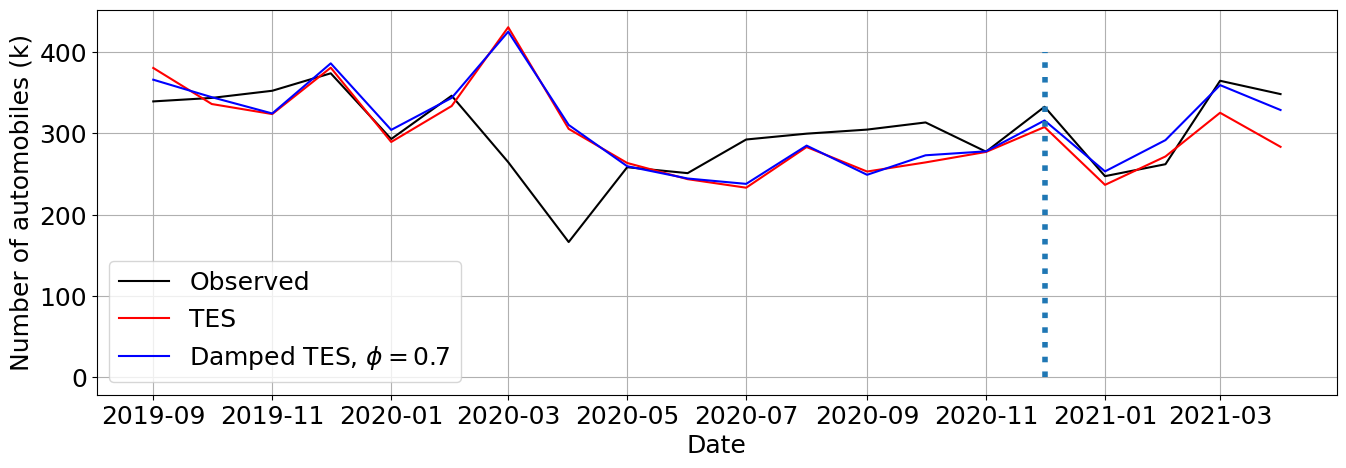

In [13]:
plt.figure(figsize=(16, 5), dpi=100)

# last 20 observations
plt.plot(df.Auto_sales[-20:], \
    color='k', label='Observed')

# TES forecasts
plt.plot(df.tes_fit[-20:], \
    color='r', label='TES')

# damped TES forecasts
plt.plot(df.tes_damp[-20:], \
    color='b', label='Damped TES, $\phi=0.7$')

# indicate forcasting start point
plt.vlines(df.index[-h], 0, 400, \
    linestyles='dotted', lw=4)

# set artists
plt.gca().set(xlabel='Date', \
    ylabel='Number of automobiles (k)')
plt.grid()
plt.legend()
plt.show()